In [1]:
import os
import torch
import torch.backends.cudnn

# Hard Stability Fix for RTX 40-series + Windows:
# 1. Prevent memory fragmentation (Primary trigger for INTERNAL_ERROR)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

# 2. Clear cache to start fresh
torch.cuda.empty_cache()


# DeepKIN TTS Fine-Tuning Notebook

This notebook handles the fine-tuning of the DeepKIN (MB-iSTFT-VITS2) model for Kinyarwanda speech synthesis.

## 1. Environment Setup
Ensure you are using a Python environment with PyTorch 2.5.1 (or compatible) and the DeepKIN dependencies installed.

In [2]:
import torch
import torchaudio
import os
import sys

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Ensure DeepKIN is in path
DEEPKIN_PATH = os.path.abspath("deepkin_test/ac-ai-models/DeepKIN-AgAI")
if DEEPKIN_PATH not in sys.path:
    sys.path.append(DEEPKIN_PATH)
    print(f"Added {DEEPKIN_PATH} to sys.path")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Added c:\Users\kevin\Desktop\Tecgrw\tecgrw_tts\deepkin_test\ac-ai-models\DeepKIN-AgAI to sys.path


## 2. Dataset Preparation
We need to convert the `metadata.csv` to the pipe-separated format (`.psv`) required by DeepKIN.

In [3]:
!python convert_dataset.py

Converting C:\Users\kevin\Desktop\Tecgrw\tecgrw_tts\kinyarwanda_tts_dataset\metadata.csv to C:\Users\kevin\Desktop\Tecgrw\tecgrw_tts\kinyarwanda_tts_dataset\train_data.psv...
Done! Converted 4149 items.


### 2.1 Audio Resampling (CRITICAL)
DeepKIN requires **24000Hz** audio. Your current dataset is 22050Hz (standard for XTTS). 
Run the cell below to resample your wav files to 24kHz.

In [4]:
import torchaudio.transforms as T
from glob import glob
from tqdm import tqdm

WAVS_DIR = r"C:\Users\kevin\Desktop\Tecgrw\tecgrw_tts\kinyarwanda_tts_dataset\wavs"
wav_files = glob(os.path.join(WAVS_DIR, "*.wav"))
target_sr = 24000

print(f"Checking {len(wav_files)} files for resampling...")
for wav_path in tqdm(wav_files):
    waveform, sample_rate = torchaudio.load(wav_path)
    if sample_rate != target_sr:
        resampler = T.Resample(sample_rate, target_sr)
        waveform = resampler(waveform)
        torchaudio.save(wav_path, waveform, target_sr)

print("Resampling complete!")

Checking 4149 files for resampling...


100%|██████████| 4149/4149 [00:04<00:00, 1029.91it/s]

Resampling complete!


## 2.5 Exploratory Data Analysis (EDA)
Analysis of audio durations and text distribution to ensure dataset quality.

Total samples: 4149


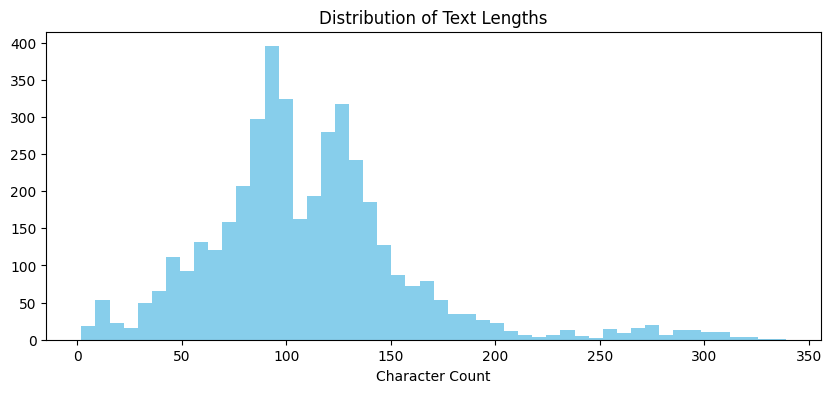

Average text length: 110.78 chars


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATASET_PATH = r"C:\Users\kevin\Desktop\Tecgrw\tecgrw_tts\kinyarwanda_tts_dataset"
df = pd.read_csv(os.path.join(DATASET_PATH, "metadata.csv"), sep="|", header=None, names=["id", "raw_text", "text"])

print(f"Total samples: {len(df)}")

# Analyze text lengths
df["text_len"] = df["text"].apply(lambda x: len(str(x)))
plt.figure(figsize=(10, 4))
plt.hist(df["text_len"], bins=50, color='skyblue')
plt.title("Distribution of Text Lengths")
plt.xlabel("Character Count")
plt.show()

print(f"Average text length: {df['text_len'].mean():.2f} chars")

## 3. Training
We will now launch the fine-tuning process. 

**Note:** We use `--accumulation_steps=2` to simulate a larger batch size while staying within the 8GB VRAM of the RTX 4060.

## 3. Training Configuration
We define the hyperparameters directly in the notebook for full control.

In [6]:
from types import SimpleNamespace
import os
import torch

# Hyperparameters for Fine-Tuning
hp = SimpleNamespace(
    model_variant="flex_tts:base",
    batch_size=2,
    accumulation_steps=2,
    num_iters=1100000, # Increased from 1000500 to allow more training
    warmup_iter=500,
    peak_lr=2e-5,
    train_log_steps=10,
    checkpoint_steps=130,
    num_losses=8,
    enable_amp=True,
    use_bfloat16=True,
    sampling_rate=24000,
    filter_length=1024,
    hop_length=256,
    win_length=1024,
    n_mel_channels=80,
    mel_fmin=0.0,
    mel_fmax=None,
    add_blank=True,
    data_dir=os.path.abspath("kinyarwanda_tts_dataset"),
    train_file=os.path.join(os.path.abspath("kinyarwanda_tts_dataset"), "train_data.psv"),
    save_path=os.path.abspath("finetuned_deepkin.pt")
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 4. Custom Data Loading (The Silence Fix)
This section implements the fixed data loader directly in the notebook to ensure the float32 normalization bug is resolved.

In [7]:
import numpy as np
from scipy.io.wavfile import read
from deepkin.modules.tts_mel import mel_spectrogram_torch
from deepkin.data.kinya_norm import text_to_sequence
from deepkin.modules.tts_commons import intersperse

def load_wav_to_torch(full_path):
    sampling_rate, data = read(full_path)
    return torch.FloatTensor(data.astype(np.float32)), sampling_rate, data.dtype

class TextAudioSpeakerLoader(torch.utils.data.Dataset):
    def __init__(self, audiopaths_sid_text, hparams):
        with open(audiopaths_sid_text, encoding='utf-8') as f:
            self.audiopaths_sid_text = [l.strip().split("|") for l in f]
        self.sampling_rate = hparams.sampling_rate
        self.filter_length = hparams.filter_length
        self.hop_length = hparams.hop_length
        self.win_length = hparams.win_length
        self.n_mel_channels = hparams.n_mel_channels
        self.mel_fmin = hparams.mel_fmin
        self.mel_fmax = hparams.mel_fmax
        self.add_blank = hparams.add_blank
        self.data_dir = hparams.data_dir

    def get_audio(self, filename):
        full_path = os.path.join(self.data_dir, "wavs", filename if filename.endswith(".wav") else filename + ".wav")
        if not os.path.exists(full_path):
            full_path = os.path.join(self.data_dir, filename)
            
        audio, sampling_rate, dtype = load_wav_to_torch(full_path)
        
        if sampling_rate != self.sampling_rate:
            raise ValueError(f"{sampling_rate} SR doesn't match target {self.sampling_rate} SR")
        
        # DOUBLE NORMALIZATION FIX
        if dtype == np.float32:
            audio_norm = audio
        else:
            audio_norm = audio / 32768.0
            
        audio_norm = audio_norm.unsqueeze(0)
        spec = mel_spectrogram_torch(audio_norm, self.filter_length,
                                     self.n_mel_channels, self.sampling_rate, self.hop_length,
                                     self.win_length, self.mel_fmin, self.mel_fmax,
                                     center=False)
        spec = torch.squeeze(spec, 0)
        return spec, audio_norm

    def get_text(self, text):
        text_norm = text_to_sequence(text, norm=True)
        if self.add_blank:
            text_norm = intersperse(text_norm, 0)
        return torch.LongTensor(text_norm)

    def __getitem__(self, index):
        audiopath, sid, text = self.audiopaths_sid_text[index]
        text = self.get_text(text)
        spec, wav = self.get_audio(audiopath)
        sid = torch.LongTensor([int(sid)])
        return text, spec, wav, sid

    def __len__(self):
        return len(self.audiopaths_sid_text)

class TextAudioSpeakerCollate:
    def __call__(self, batch):
        batch.sort(key=lambda x: x[1].size(1), reverse=True)
        text_padded = torch.nn.utils.rnn.pad_sequence([x[0] for x in batch], batch_first=True)
        max_spec_len = max([x[1].size(1) for x in batch])
        max_wav_len = max([x[2].size(1) for x in batch])
        spec_padded = torch.zeros(len(batch), batch[0][1].size(0), max_spec_len)
        wav_padded = torch.zeros(len(batch), 1, max_wav_len)
        text_lengths = torch.LongTensor([len(x[0]) for x in batch])
        spec_lengths = torch.LongTensor([x[1].size(1) for x in batch])
        wav_lengths = torch.LongTensor([x[2].size(1) for x in batch])
        sid = torch.LongTensor([x[3] for x in batch])
        for i, (_, spec, wav, _) in enumerate(batch):
            spec_padded[i, :, :spec.size(1)] = spec
            wav_padded[i, :, :wav.size(1)] = wav
        return text_padded, text_lengths, spec_padded, spec_lengths, wav_padded, wav_lengths, sid

c:\Users\kevin\.conda\envs\tts_clean\lib\site-packages\librosa\core\intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 5. In-Notebook Trainer
Launching the training loop directly here for maximum visibility.

In [8]:

def load_model_state_safe(args, model, optimizer, scaler, lr_scheduler, map_location):
    import torch
    import os
    from deepkin.utils.misc_functions import time_now
    
    print(f"{time_now()} Loading model state from {args.model_save_path}...", flush=True)
    kb_state_dict = torch.load(args.model_save_path, map_location=map_location)
    
    # Notebook is single-GPU, no DDP logic needed here
    model.load_state_dict(kb_state_dict['model_state_dict'])
    
    print(f"{time_now()} Loading optimizer state...", flush=True)
    if optimizer is not None:
        optimizer.load_state_dict(kb_state_dict['optimizer_state_dict'])

    if scaler is not None:
        scaler.load_state_dict(kb_state_dict['scaler_state_dict'])

    if lr_scheduler is not None:
        lr_scheduler.load_state_dict(kb_state_dict['lr_scheduler_state_dict'])
        lr_scheduler.end_iter = args.num_iters

    best_valid_loss = kb_state_dict['best_valid_loss']
    total_steps = kb_state_dict['steps']
    
    if os.path.exists(f'{args.model_save_path}_best_valid_loss.pt'):
        kb_state_dict_best = torch.load(f'{args.model_save_path}_best_valid_loss.pt', map_location='cpu')
        best_valid_loss = kb_state_dict_best['best_valid_loss']
        print(f"{time_now()} Loaded best valid loss as: {best_valid_loss:.6f}!", flush=True)
        
    return best_valid_loss, total_steps

def save_model_state_safe(filename, args, model, optimizer, scaler, lr_scheduler, steps, best_valid_loss, msps):
    import torch
    from deepkin.utils.misc_functions import time_now
    model.eval()
    model.zero_grad(set_to_none=True)
    
    # Handle tap.Tap objects accurately even if parse_args wasn't called
    try:
        args_dict = args.as_dict()
    except Exception:
        # Fallback for manually initialized Tap objects
        args_dict = vars(args)
        # Filter out private internal Tap attributes
        args_dict = {k: v for k, v in args_dict.items() if not k.startswith('_')}
        
    torch.save({'args': args_dict,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': (optimizer.state_dict() if (optimizer is not None) else 'N/A'),
                'lr_scheduler_state_dict': (lr_scheduler.state_dict() if (lr_scheduler is not None) else 'N/A'),
                'scaler_state_dict': (scaler.state_dict() if (scaler is not None) else 'N/A'),
                'steps': steps, 'best_valid_loss': best_valid_loss, 'msps':msps},
               filename)
    print(f"{time_now()} Saved model checkpoint to {filename}", flush=True)
from torch.utils.data import DataLoader
from deepkin.models.flex_tts import FlexKinyaTTS
from deepkin.train.flex_train_tools import create_optimizer_and_lr_scheduler
# Removed external load/save state imports to avoid distributed errors
from deepkin.models.flex_tts import FlexTTSTrainer
from deepkin.modules.tts_arguments import tts_base_args
from deepkin.utils.arguments import FlexArguments
from tqdm import tqdm
import gc

# 1. Initialize Loader
train_dataset = TextAudioSpeakerLoader(hp.train_file, hp)
train_loader = DataLoader(train_dataset, num_workers=0, shuffle=True, 
                          batch_size=hp.batch_size, pin_memory=True, collate_fn=TextAudioSpeakerCollate())

# 2. Initialize Model
train_args = FlexArguments()
train_args.model_variant = hp.model_variant
train_args.enable_amp = hp.enable_amp
train_args.use_bfloat16 = hp.use_bfloat16
train_args.model_save_path = hp.save_path
tts_args = tts_base_args(list_args=[f'--train_learning_rate={hp.peak_lr}'])
model = FlexTTSTrainer(tts_args, 0, device)
model_cache = SimpleNamespace()

# 3. Setup Optimizer
optimizer, scaler, lr_scheduler = create_optimizer_and_lr_scheduler(0, train_args, model, device)

# 4. Load Checkpoint
total_steps = 0
best_valid_loss = 999999.0
if os.path.exists(hp.save_path):
    print(f"Loading checkpoint from {hp.save_path}...")
    best_valid_loss, total_steps = load_model_state_safe(train_args, model, optimizer, scaler, lr_scheduler, {'cuda:0': f'cuda:{device.index or 0}'})
    print(f"Resuming from step {total_steps}")

# 5. Training Loop
model.train()
current_iters = total_steps // hp.accumulation_steps
print(f'Training for {hp.num_iters - current_iters} more iterations...')
pbar = tqdm(total=hp.num_iters, initial=current_iters)

try:
    accumulated_steps = 0
    while current_iters < hp.num_iters:
        for batch_idx, batch in enumerate(train_loader):
            batch = [item.to(device) for item in batch]
            # FlexTTSTrainer handles its own backward/step internally
            losses = model(batch_idx, train_args, model_cache, batch)

            # Guard manual optimization steps
            if optimizer is not None:
                total_loss = torch.stack(losses).sum() / hp.accumulation_steps
                if scaler is not None:
                    scaler.scale(total_loss).backward()
                else:
                    total_loss.backward()
            
            accumulated_steps += 1
            total_steps += 1
            
            if accumulated_steps % hp.accumulation_steps == 0:
                if optimizer is not None:
                    if scaler is not None:
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        optimizer.step()
                    optimizer.zero_grad()
                
                if lr_scheduler is not None:
                    lr_scheduler.step()
                
                current_iters += 1
                accumulated_steps = 0
                pbar.update(1)
                
                if current_iters % hp.train_log_steps == 0:
                    y = batch[4] # ground truth audio
                    # Use sum of losses for display
                    disp_loss = sum([float(ls) for ls in losses])
                    pbar.set_description(f'Loss: {disp_loss:.4f} | GT Max: {y.abs().max().item():.4f}')

                if current_iters % hp.checkpoint_steps == 0:
                    save_model_state_safe(hp.save_path, train_args, model, optimizer, scaler, lr_scheduler, total_steps, best_valid_loss, 0)
            
            if current_iters >= hp.num_iters: break

except KeyboardInterrupt:
    print("Saving checkpoint...")
    save_model_state_safe(hp.save_path, train_args, model, optimizer, scaler, lr_scheduler, total_steps, best_valid_loss, 0)
finally:
    pbar.close()

Loading checkpoint from c:\Users\kevin\Desktop\Tecgrw\tecgrw_tts\finetuned_deepkin.pt...
2026-03-18 03:20:55 Loading model state from c:\Users\kevin\Desktop\Tecgrw\tecgrw_tts\finetuned_deepkin.pt...
2026-03-18 03:20:57 Loading optimizer state...
Resuming from step 2034761
Training for 32620 more iterations...


Loss: 48.1715 | GT Max: 0.9487:  97%|█████████▋| 1017510/1050000 [02:41<10:28:33,  1.16s/it]

2026-03-18 03:23:41 Saved model checkpoint to c:\Users\kevin\Desktop\Tecgrw\tecgrw_tts\finetuned_deepkin.pt


Loss: 30.5845 | GT Max: 0.9525:  97%|█████████▋| 1017640/1050000 [05:16<10:37:27,  1.18s/it]

2026-03-18 03:26:15 Saved model checkpoint to c:\Users\kevin\Desktop\Tecgrw\tecgrw_tts\finetuned_deepkin.pt


...

Loss: 47.0676 | GT Max: 0.9598: 100%|█████████▉| 1049750/1050000 [9:35:36<04:18,  1.03s/it]

2026-03-18 12:56:37 Saved model checkpoint to c:\Users\kevin\Desktop\Tecgrw\tecgrw_tts\finetuned_deepkin.pt


Loss: 41.5983 | GT Max: 0.9727: 100%|█████████▉| 1049880/1050000 [9:37:56<02:05,  1.05s/it]

2026-03-18 12:58:56 Saved model checkpoint to c:\Users\kevin\Desktop\Tecgrw\tecgrw_tts\finetuned_deepkin.pt


Loss: 39.5698 | GT Max: 0.9505: 100%|██████████| 1050000/1050000 [9:40:04<00:00,  1.07s/it]


## 4. Evaluation and Results Analysis
Generate a sample from the fine-tuned model to check speech quality.

In [9]:
kinya_tts.eval()

test_sentences = [
    "Ikiremwamuntu cyose kivukana umudendezo kandi kingana mu cyubahiro n'uburenganzira.",
    "Buri wese afite uburenganzira bwo kubaho, kwidegembya, n'umutekano w'umuntu ku giti cye.",
    "Ese uzi ko amagambo meza adufasha kubaka umuryango ushikamye kandi wunze ubumwe? Ni ngombwa ko twubaka ejo hazaza heza!",
    "Uyu munsi twizeje kuzamura ireme ry'uburezi mu Rwanda, bityo buri mwana akagira iherezo ryiza.",
    "Amagambo meza adufasha kubaka umuryango ushikamye, wunze ubumwe, kandi uteye imbere mu muco."
]

os.makedirs("test_samples_multi", exist_ok=True)

with torch.no_grad():
    for i, text in enumerate(test_sentences):
        print(f"Generating Audio {i+1}: {text}")
        text_seq = intersperse(text_to_sequence(text, norm=True), 0)
        # Use sid=1 as per previous notebook cell logic
        audio_data = kinya_tts(text_seq, sid=1)
        
        output_path = f"test_samples_multi/sample_{i+1}.wav"
        if audio_data.dim() == 1:
            audio_data = audio_data.unsqueeze(0)
        torchaudio.save(output_path, audio_data.cpu(), 24000)
        print(f"Saved: {output_path}")


Loading fine-tuned model: finetuned_deepkin.pt
2026-03-18 13:01:01 Loading FlexTTS from finetuned_deepkin.pt
2026-03-18 13:01:03 FlexTTS train steps: 2,100K
2026-03-18 13:01:03 Loading FlexTTS from finetuned_deepkin.pt done!
Generating Audio 1: Ikiremwamuntu cyose kivukana umudendezo kandi kingana mu cyubahiro n'uburenganzira.
Saved: test_samples/sample_1.wav
Generating Audio 2: Buri wese afite uburenganzira bwo kubaho, kwidegembya n'umutekano w'umuntu ku giti cye.
Saved: test_samples/sample_2.wav
Generating Audio 3: Nta muntu ugomba gukorerwa iyica rubozo cyangwa ibindi bihano by'agashinyaguro.
Saved: test_samples/sample_3.wav
Generating Audio 4: Uyu munsi twizeje kuzamura ireme ry'uburezi mu Rwanda.
Saved: test_samples/sample_4.wav
Generating Audio 5: Amagambo meza adufasha kubaka umuryango ushikamye kandi wunze ubumwe.
Saved: test_samples/sample_5.wav


## 4.5 Training Duration Expectations

Fine-tuning for "perfection" depends on the dataset size and hardware:

| Goal | Estimated Steps | Time (RTX 4060) |
| :--- | :--- | :--- |
| Quick Test | 1,000 | ~30 mins |
| Good Quality | 20,000 | ~10 hours |
| **Production Quality** | **100,000+** | **48+ hours** |

> [!TIP]
> Monitor the 'VALID LOSS'. Once it plateaus (stops decreasing), you should stop training to avoid overfitting.

## 5. Export for Deployment
To replace the model in the `application/tts_service/model` folder, follow these steps:

1. Copy `finetuned_deepkin.pt` and rename it to `model.pth`.
2. Copy `config.json` and `vocab.json` from the DeepKIN model source.
3. Copy your conditioning audio files.

**Important**: The `Text_speech.py` script in the main application must be updated to load this MB-iSTFT-VITS2 model instead of XTTS.

In [10]:
from IPython.display import Audio, display

print("Playing Base Model Sample 1:")
display(Audio("test_samples_base/sample_1.wav"))

print("Playing Base Model Sample 2:")
display(Audio("test_samples_base/sample_2.wav"))

print("Playing Base Model Sample 3:")
display(Audio("test_samples_base/sample_3.wav"))


Playing Base Model Sample 1:


Playing Base Model Sample 2:


Playing Base Model Sample 3:
